In [42]:
import pandas as pd

In [43]:

df=pd.read_csv('/content/ai-impact-jobs-layoff-risk-dataset.csv')

In [17]:

df.head(10)

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium
5,45,PhD,9,Telecom,Network Engineer,Large,Entry,72,33,54,Medium,4,5,69,9,High
6,48,Bachelor's,10,IT,Software Engineer,Small,Entry,46,63,63,Medium,2,7,45,9,Medium
7,23,Master's,2,Retail,Store Manager,Medium,Mid,36,37,77,Low,2,0,27,3,Medium
8,24,Bachelor's,3,IT,ML Engineer,Large,Entry,41,62,90,Low,1,1,20,8,Low
9,48,Master's,6,Retail,Inventory Analyst,Small,Senior,84,8,81,Medium,2,5,67,29,Medium


In [18]:
import numpy as np


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns


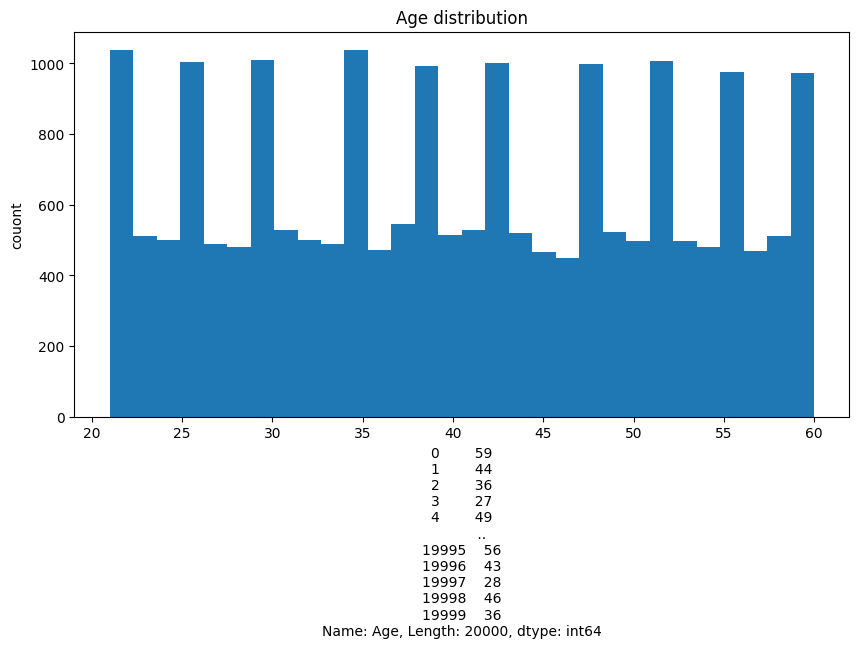

In [20]:
plt.figure(figsize=(10,5))
plt.hist(df['Age'],bins=30)
plt.title("Age distribution")
plt.xlabel(df['Age'])
plt.ylabel('couont')
plt.show()

Text(0, 0.5, 'Count')

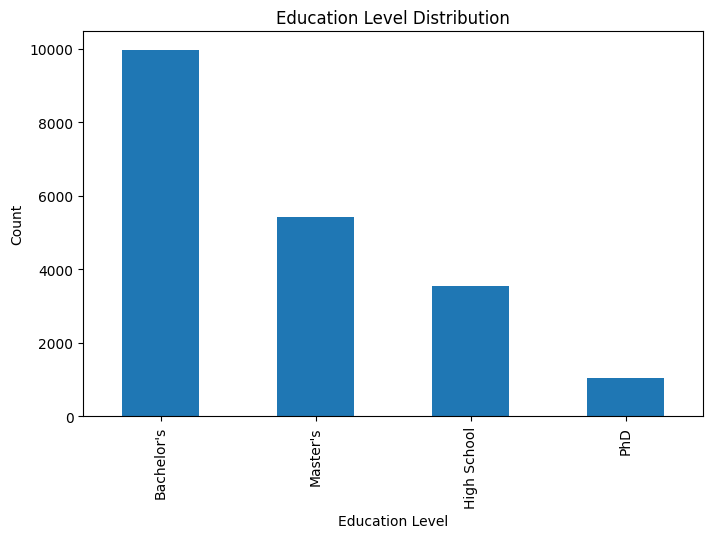

In [21]:
df['Education_Level'].value_counts().plot(
    kind='bar',
    figsize=(8,5))
plt.title('Education Level Distribution')
plt.xlabel('Education Level')
plt.ylabel('Count')


Text(0, 0.5, 'Count')

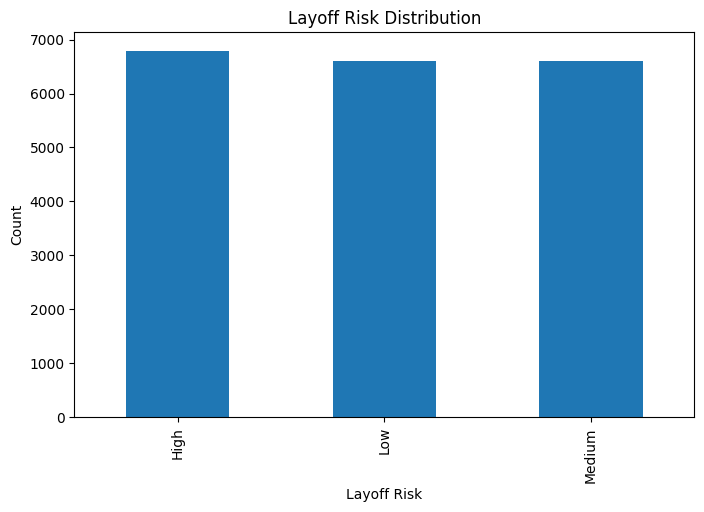

In [22]:
df['Layoff_Risk'].value_counts().plot(
    kind='bar',
    figsize=(8,5))
plt.title('Layoff Risk Distribution')
plt.xlabel('Layoff Risk')
plt.ylabel('Count')


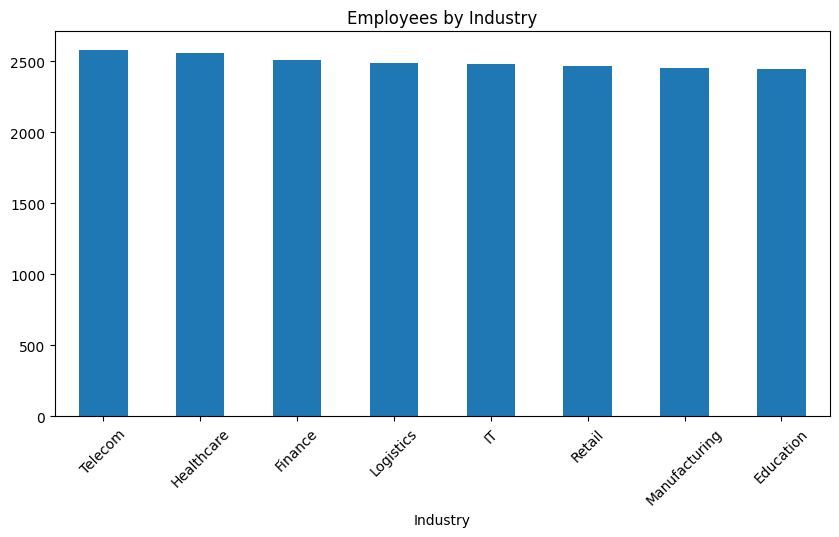

In [23]:
df["Industry"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.xticks(rotation=45)
plt.title("Employees by Industry")
plt.show()

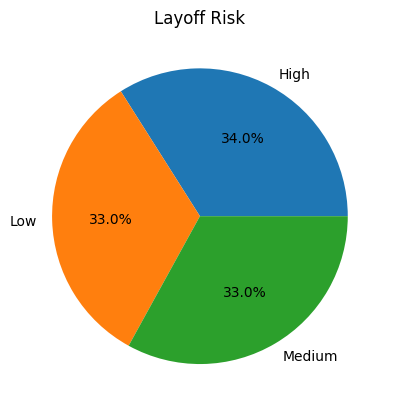

In [24]:
df["Layoff_Risk"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Layoff Risk")
plt.show()

<Axes: xlabel='Job_Level'>

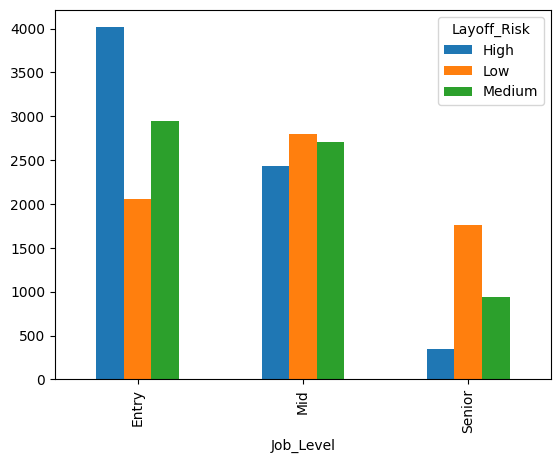

In [25]:
pd.crosstab(
    df["Job_Level"],
    df["Layoff_Risk"]
).plot(kind="bar")

<Axes: xlabel='AI_Adoption_Level'>

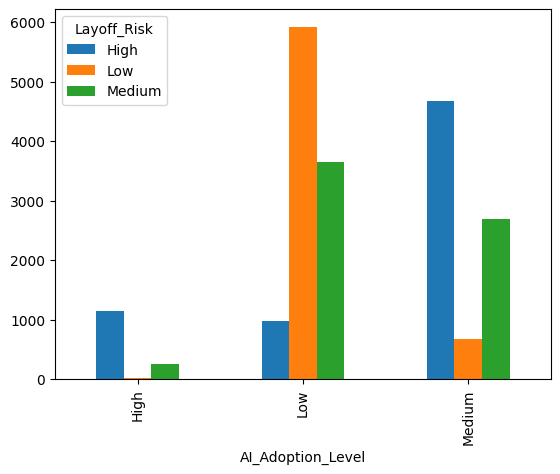

In [26]:
pd.crosstab(
    df["AI_Adoption_Level"],
    df["Layoff_Risk"]
).plot(kind="bar")

In [27]:
#for ordinal data i will use map function insead of using ordinal encodinng
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Tasks_Automated_Percentage  20000 non-null  in

In [28]:
df['Education_Level'].unique()

array(["Master's", "Bachelor's", 'High School', 'PhD'], dtype=object)

In [29]:
levels={
    'High School':0,
    "Bachelor's":1,
    "Master's":2,
    'PhD':3
}
df['Education_Level']=df['Education_Level'].map(levels)

In [30]:
df['Industry'].unique()

array(['Finance', 'Manufacturing', 'Retail', 'Telecom', 'IT', 'Logistics',
       'Healthcare', 'Education'], dtype=object)

In [31]:
df=pd.get_dummies(
    df,
    columns=['Industry','Job_Role'],
    drop_first=True
)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             20000 non-null  int64 
 1   Education_Level                 20000 non-null  int64 
 2   Years_of_Experience             20000 non-null  int64 
 3   Company_Size                    20000 non-null  object
 4   Job_Level                       20000 non-null  object
 5   Routine_Task_Percentage         20000 non-null  int64 
 6   Creativity_Requirement          20000 non-null  int64 
 7   Human_Interaction_Level         20000 non-null  int64 
 8   AI_Adoption_Level               20000 non-null  object
 9   Number_of_AI_Tools_Used         20000 non-null  int64 
 10  AI_Usage_Hours_Per_Week         20000 non-null  int64 
 11  Tasks_Automated_Percentage      20000 non-null  int64 
 12  AI_Training_Hours               20000 non-null

In [33]:
company_mapping = {
    'Small': 0,
    'Medium': 1,
    'Large': 2
}

job_mapping = {
    'Entry': 0,
    'Mid': 1,
    'Senior': 2,
    'Executive': 3
}

ai_mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

target_mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

df['Job_Level'] = df['Job_Level'].map(job_mapping)
df['Company_Size'] = df['Company_Size'].map(company_mapping)
df['AI_Adoption_Level'  ] = df['AI_Adoption_Level'].map(ai_mapping)
df['Layoff_Risk'] = df['Layoff_Risk'].map(target_mapping)


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Age                             20000 non-null  int64
 1   Education_Level                 20000 non-null  int64
 2   Years_of_Experience             20000 non-null  int64
 3   Company_Size                    20000 non-null  int64
 4   Job_Level                       20000 non-null  int64
 5   Routine_Task_Percentage         20000 non-null  int64
 6   Creativity_Requirement          20000 non-null  int64
 7   Human_Interaction_Level         20000 non-null  int64
 8   AI_Adoption_Level               20000 non-null  int64
 9   Number_of_AI_Tools_Used         20000 non-null  int64
 10  AI_Usage_Hours_Per_Week         20000 non-null  int64
 11  Tasks_Automated_Percentage      20000 non-null  int64
 12  AI_Training_Hours               20000 non-null  int64
 13  L

In [35]:
x=df.drop('Layoff_Risk',axis=1)
y=df['Layoff_Risk']

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
x_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [39]:
predictions=dt.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predictions)

0.817

In [55]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=200)
rf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=200)

In [56]:

predict_random=rf.predict(X_test)
accuracy_score(y_test,rf.predict(X_test))

0.88525

In [58]:
from xgboost import XGBClassifier

In [59]:
xgb=XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_child_weight=1,
    random_state=42,
    eval_metric="mlogloss"
)
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [60]:
xg_predictions=xgb.predict(X_test)
accuracy_score(y_test,xg_predictions)

0.88425

In [64]:
import joblib

joblib.dump(rf, "random_forest_model.joblib")
joblib.dump(xgb, "xgboost_model.joblib")


['xgboost_model.joblib']

In [65]:
X = df.drop("Layoff_Risk", axis=1)

feature_columns = X.columns.tolist()

import joblib
joblib.dump(feature_columns, "feature_columns.joblib")

['feature_columns.joblib']